<a href="https://colab.research.google.com/github/jonanthanaquino/api-estudos/blob/main/vision_computer_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# IMPORTS
# =========================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

# =========================
# CONFIGURAÇÃO
# =========================
class Config:
    data_dir = "/content/drive/MyDrive/teste-IA/teste"  # caminho do dataset (3 pastas dentro)
    num_epochs = 80
    batch_size = 32
    lr = 1e-3
    weight_decay = 1e-5
    num_classes = 3
    log_file = data_dir + "/training_log.txt"

# =========================
# DATASET
# =========================
def get_dataloaders(config):
    transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    dataset = datasets.ImageFolder(root=config.data_dir, transform=transform)

    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size

    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)

    return train_loader, val_loader, dataset.classes

# =========================
# MODELO (TRANSFER LEARNING)
# =========================
def get_model(config):
    model = models.resnet18(pretrained=True)

    # congela base
    for param in model.parameters():
        param.requires_grad = False

    # substitui última camada
    model.fc = nn.Linear(model.fc.in_features, config.num_classes)

    return model

# =========================
# LOGGER
# =========================
def log_epoch(log_file, text):
    with open(log_file, "a") as f:
        f.write(text + "\n")

# =========================
# TREINAMENTO
# =========================
def train_model(config):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_loader, val_loader, classes = get_dataloaders(config)

    model = get_model(config).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=config.lr)

    # limpa log anterior
    open(config.log_file, "w").close()

    print("Classes:", classes)
    print("Iniciando treinamento...\n")

    for epoch in range(config.num_epochs):

        # ===== TREINO =====
        model.train()
        train_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ===== VALIDAÇÃO =====
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = 100 * correct / total

        # ===== LOG =====
        log_text = (
            f"Epoch {epoch+1}/{config.num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.2f}%"
        )

        print(log_text)
        log_epoch(config.log_file, log_text)

        torch.save(model.state_dict(), config.data_dir + "/model.pth")
        print("Modelo salvo!")

    print("\nTreinamento finalizado!")

# =========================
# EXECUÇÃO
# =========================
config = Config()
train_model(config)




/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Classes: ['blight', 'early_blight', 'healthy']
Iniciando treinamento...

Epoch 1/80 | Train Loss: 0.5598 | Val Loss: 0.2849 | Val Acc: 92.81%
Modelo salvo!
Epoch 2/80 | Train Loss: 0.2412 | Val Loss: 0.1750 | Val Acc: 96.29%
Modelo salvo!
Epoch 3/80 | Train Loss: 0.1681 | Val Loss: 0.1328 | Val Acc: 97.68%
Modelo salvo!
Epoch 4/80 | Train Loss: 0.1393 | Val Loss: 0.1107 | Val Acc: 97.91%
Modelo salvo!
Epoch 5/80 | Train Loss: 0.1245 | Val Loss: 0.1002 | Val Acc: 98.14%
Modelo salvo!
Epoch 6/80 | Train Loss: 0.1208 | Val Loss: 0.0729 | Val Acc: 98.61%
Modelo salvo!
Epoch 7/80 | Train Loss: 0.0891 | Val Loss: 0.0684 | Val Acc: 98.61%
Modelo salvo!
Epoch 8/80 | Train Loss: 0.0833 | Val Loss: 0.0750 | Val Acc: 97.91%
Modelo salvo!
Epoch 9/80 | Train Loss: 0.1078 | Val Loss: 0.0548 | Val Acc: 98.84%
Modelo salvo!
Epoch 10/80 | Train Loss: 0.0745 | Val Loss: 0.0486 | Val Acc: 99.54%
Modelo salvo!
Epoch 11/80 | Train Loss: 0.0625 | Val Loss: 0.0481 | Val Acc: 99.54%
Modelo salvo!
Epoch 12/80 

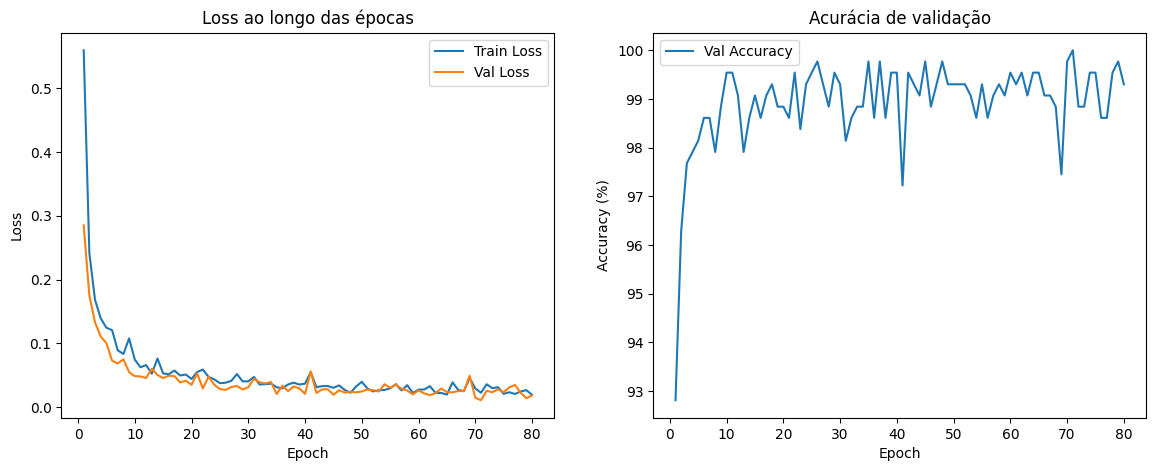

In [ ]:
import matplotlib.pyplot as plt

log_path = "/content/drive/MyDrive/teste-IA/teste/training_log.txt"

epochs = []
train_losses = []
val_losses = []
val_accs = []

with open(log_path, "r") as f:
    for line in f:
        # exemplo:
        # Epoch 1/20 | Train Loss: 0.82 | Val Loss: 0.65 | Val Acc: 78.21%

        parts = line.strip().split("|")

        epoch = int(parts[0].split()[1].split("/")[0])
        train_loss = float(parts[1].split(":")[1])
        val_loss = float(parts[2].split(":")[1])
        val_acc = float(parts[3].split(":")[1].replace("%",""))

        epochs.append(epoch)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

# ===== PLOTS =====
plt.figure(figsize=(14,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss ao longo das épocas")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, val_accs, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Acurácia de validação")
plt.legend()

plt.show()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



Resumo Final do Desempenho do Modelo:

              precision    recall  f1-score   support

      blight       0.99      1.00      0.99      1000
early_blight       1.00      1.00      1.00      1000
     healthy       1.00      0.95      0.98       152

    accuracy                           0.99      2152
   macro avg       1.00      0.98      0.99      2152
weighted avg       0.99      0.99      0.99      2152



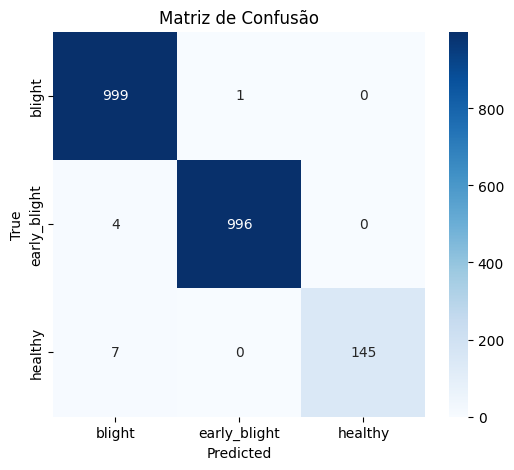

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from torchvision import datasets, transforms, models
import torch.nn as nn
from torch.utils.data import DataLoader

# ===== CONFIG =====
DATA_DIR = "/content/drive/MyDrive/teste-IA/teste"
MODEL_PATH = DATA_DIR + "/model.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== TRANSFORM (SEM AUGMENTATION) =====
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder(root=DATA_DIR, transform=transform)
loader = DataLoader(dataset, batch_size=32, shuffle=False)

class_names = dataset.classes
num_classes = len(class_names)

# ===== MODELO =====
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, num_classes)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()

# ===== INFERÊNCIA =====
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())

# ===== RELATÓRIO =====
print("\nResumo Final do Desempenho do Modelo:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

# ===== MATRIZ DE CONFUSÃO =====
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Matriz de Confusão")
plt.show()

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

# ===== CONFIG =====
DATA_DIR = "/content/drive/MyDrive/teste-IA/teste"
MODEL_PATH = DATA_DIR + "/model.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== CLASSES (mesma ordem do treino!) =====
# Isso vem do ImageFolder — coloque manualmente se necessário
class_names = ['early_blight', 'late_blight', 'healthy']  # ajuste conforme seu dataset

# ===== TRANSFORM =====
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ===== MODELO =====
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, len(class_names))

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()

# ===== FUNÇÃO DE INFERÊNCIA =====
def predict_image(img_path):
    # carregar imagem
    image = Image.open(img_path).convert("RGB")

    # aplicar transformações
    image = transform(image)

    # adicionar dimensão de batch
    image = image.unsqueeze(0).to(device)

    # inferência
    with torch.no_grad():
        outputs = model(image)

        # probabilidades
        probs = torch.nn.functional.softmax(outputs, dim=1)
        conf, pred = torch.max(probs, 1)

    predicted_class = class_names[pred.item()]
    confidence = conf.item()

    return predicted_class, confidence


Classe prevista: late_blight
Confiança: 0.7246


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
# ===== TESTE =====
img_path = "/content/drive/MyDrive/teste-IA/teste/early_blight/6905.JPG"

classe, confianca = predict_image(img_path)

print(f"Classe prevista: {classe}")
print(f"Confiança: {confianca:.4f}")

Classe prevista: late_blight
Confiança: 0.9997
